# London air quality analysis

* Author: Andrew Sivanesan
* Date: 1st Feb 2026

## Executive summary

TBC

## Background

TBC

## Sources

* London Atmospheric Emissions Inventory 2022 (grid emissions summary). London Datastore (link [here](https://data.london.gov.uk/dataset/london-atmospheric-emissions-inventory-laei-2022-2lg5g/))
* May 2025 Local Authority District (LAD) boundaries (filtered for Kingston Upon Thames). Open Geography Portal - Office for National Statistics. (link [here](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2025-boundaries-uk-bfc-v2/explore?filters=eyJMQUQyNU5NIjpbIktpbmdzdG9uIHVwb24gVGhhbWVzIl0sIlNoYXBlX19BcmVhIjpbMjg4OTY3OS41Mjg0MzQ3NTM0LDI2MTU4NjY5Nzc0Ljk1MjYzN10sIlNoYXBlX19MZW5ndGgiOls5NDA0LjcxODk3MzQxNTg5Myw1MjM3NTA3LjM1ODU0MDQ2OF19&location=55.340000%2C-3.316939%2C5))
* Transport for London (TfL)'s air quality page (link [here](https://tfl.gov.uk/corporate/about-tfl/air-quality)))
* Questions to the Mayor about car emissions - 9th Oct 2025 (link [here](https://www.london.gov.uk/who-we-are/what-london-assembly-does/questions-mayor/find-an-answer/car-emissions#:~:text=Answer&text=Please%20find%20information%20on%20cars,2025%20(the%20latest%20available))

## Use of generative AI

Google Gemini was used to answer questions about Python coding syntax and geospatial data visualisation as well as contextual questions about London air quality. I confirmed accuracy of responses by viewing the source web pages.

FixMe(20260214)

* To enhance visual simplicity: replace map markers with choropleth map. Will need to join Kingston grid square polygons to Kingston grid square emissions data.
* Consider whether there's value in producing the same map visual using LAEI 2019 data for comparison.
* Do desk research into the grid squares with anomalously large C02 emissions per annum to understand why emissions would be so high.

In [1]:
import pandas as pd
from pyproj import CRS, Transformer
import seaborn as sns
import matplotlib.pyplot as plt
import folium
import geopandas as gpd
#from folium.plugins import HeatMap

## Data preparation

In [2]:
# Initialise a transformer that converts eastings and northings from the British National Grid coordinate reference system (CRS) to latitudes and longitudes in the WGS 1984 ellipsoid CRS
transformer = Transformer.from_crs("EPSG:27700", "EPSG:4326")

In [3]:
# define the name of the files to be read into this notebook
fname = "EmissionsByGridID_2022to2030.csv"
fname_boundary = "KingstonUponThamesBoundary.geojson"

In [9]:
# read in the file
df = pd.read_csv(fname)

# define filter condition
cond = (df["Year"] == 2022) & (df["Borough"] == "Kingston") & (df["Sector"] == "Road Transport")

# filter the data
kingston_road_transport = df[cond].copy()

# create latitude and longitude columns
# This cell takes around 30 seconds to run
kingston_road_transport["Latitude"] = kingston_road_transport.apply(lambda x: transformer.transform(x["easting"], x["northing"])[0], axis=1)
kingston_road_transport["Longitude"] = kingston_road_transport.apply(lambda x: transformer.transform(x["easting"], x["northing"])[1], axis=1)

## Exploratory data analysis (all Kingston road transport emissions for 2022)

* Looking at the mean, median, upper quartile and maximum values: **carbon dioxide (co2)** is by far the largest of all the pollutants (in terms of tonnes per annum)
* There are multiple pollutants for which we have no data (e.g. bap, cd, c4h6 etc.)
* **All the pollutants are strongly positively correlated with each other**. Therefore we can reasonably focus the analysis on CO2 as a proxy for emissions across all pollutants. Any reduction in CO2 emissions will reduce emissions of all other pollutants.
* There are **1,545 rows** of Kingston road transport data.
* All columns are fully populated i.e. there are **no missing values.**
* **Petrol cars** have by far the greatest median annual carbon dioxide (CO2) emissions (874 tonnes per annum) of all types of road vehicle. This is most likely because, according to the London Assembly, **petrol cars constituted 66% of cars licensed in London at the end of 2020.**

In [10]:
pollutant_cols = ['bap', 'cd', 'c4h6', 'c6h6', 'ch4', 'co', 'co2', 'hc', 'hcl', 'hg', 'n2o', 'nh3', 'nmvoc', 'nox', 'pb', 'pcb', 'pm10', 'pm2.5', 'so2']

kingston_road_transport[pollutant_cols].describe()

,bap,cd,c4h6,c6h6,ch4,co,co2,hc,hcl,hg,n2o,nh3,nmvoc,nox,pb,pcb,pm10,pm2.5,so2
count,0.0,0.0,0.0,0.0,885.000000,0.0,885.000000,0.0,0.0,0.0,885.000000,0.0,0.0,885.000000,0.0,0.0,885.000000,885.000000,0.0
mean,NaN,NaN,NaN,NaN,0.007166,NaN,193.111507,NaN,NaN,NaN,0.006342,NaN,NaN,0.351772,NaN,NaN,0.063597,0.030650,NaN
std,NaN,NaN,NaN,NaN,0.017247,NaN,475.144294,NaN,NaN,NaN,0.014769,NaN,NaN,0.881882,NaN,NaN,0.154698,0.074069,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,0.000157,NaN,NaN,0.001194,0.000595,NaN
50%,NaN,NaN,NaN,NaN,0.000298,NaN,23.514260,NaN,NaN,NaN,0.000733,NaN,NaN,0.028583,NaN,NaN,0.007006,0.003601,NaN
75%,NaN,NaN,NaN,NaN,0.001925,NaN,144.500248,NaN,NaN,NaN,0.005167,NaN,NaN,0.212111,NaN,NaN,0.040372,0.019270,NaN
max,NaN,NaN,NaN,NaN,0.130145,NaN,4707.255276,NaN,NaN,NaN,0.134449,NaN,NaN,7.940952,NaN,NaN,1.411963,0.666482,NaN


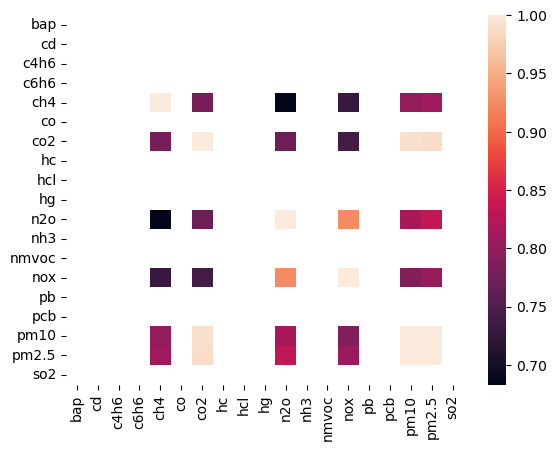

In [11]:
# Calculate the correlation matrix for the pollutants
corr = kingston_road_transport[pollutant_cols].corr()

# plot the correlation heatmap
# correlations between 0.7 and 1 i.e. strong positive correlation between pollutants
sns.heatmap(corr)
plt.show()

In [12]:
# define the columns to select
cols = ["LAEI 1km2 ID", "Latitude", "Longitude", "Source", "co2", "Emissions Unit"]

# apply filters and select columns
kingston_road_transport = kingston_road_transport[cols]

#kingston_road_transport.head()

In [13]:
kingston_road_transport.describe()

,LAEI 1km2 ID,Latitude,Longitude,co2
count,885.000000,885.000000,885.000000,885.000000
mean,12236.118644,51.387458,-0.287401,193.111507
std,589.241846,0.030658,0.025594,475.144294
min,11252.000000,51.322682,-0.329473,0.000000
25%,11767.000000,51.366787,-0.311829,0.000000
50%,12114.000000,51.393323,-0.285099,23.514260
75%,12628.000000,51.411937,-0.268372,144.500248
max,13484.000000,51.438688,-0.239967,4707.255276


In [14]:
# There are no null values to deal with
kingston_road_transport.isnull().sum()

LAEI 1km2 ID      0
Latitude          0
Longitude         0
Source            0
co2               0
Emissions Unit    0
dtype: int64

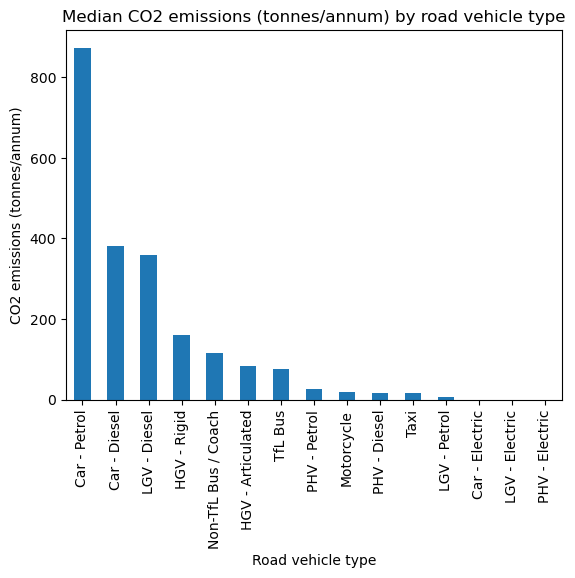

In [15]:
kingston_road_transport.groupby("Source")["co2"].median().sort_values(ascending=False).plot.bar(x="Source")
plt.title("Median CO2 emissions (tonnes/annum) by road vehicle type")
plt.xlabel("Road vehicle type")
plt.ylabel("CO2 emissions (tonnes/annum)")
plt.show()

## Exploratory data analysis (petrol cars)

* CO2 emissions for petrol cars is right-skewed. There are **four grid squares with outlier CO2 emissions (more than 4,000 tonnes per annum)**. Note: there are **four grid squares where CO2 emissions for petrol cars is zero.**

In [16]:
petrol_cars = kingston_road_transport[kingston_road_transport["Source"] == "Car - Petrol"]
petrol_cars.head()

,LAEI 1km2 ID,Latitude,Longitude,Source,co2,Emissions Unit
415734,11253.0,51.438475,-0.253311,Car - Petrol,848.124716,tonnes/annum
415765,11593.0,51.421343,-0.311498,Car - Petrol,159.352206,tonnes/annum
415766,11595.0,51.420925,-0.282747,Car - Petrol,1338.892548,tonnes/annum
415769,11597.0,51.420500,-0.253997,Car - Petrol,2004.961088,tonnes/annum
415805,11937.0,51.403367,-0.312160,Car - Petrol,1024.020343,tonnes/annum


In [17]:
petrol_cars.describe()

,LAEI 1km2 ID,Latitude,Longitude,co2
count,59.000000,59.000000,59.000000,59.000000
mean,12236.118644,51.387458,-0.287401,1169.595821
std,593.963951,0.030903,0.025799,1169.662386
min,11252.000000,51.322682,-0.329473,0.000000
25%,11767.500000,51.366893,-0.311663,321.778195
50%,12114.000000,51.393323,-0.285099,873.818508
75%,12627.500000,51.411832,-0.268542,1529.100721
max,13484.000000,51.438688,-0.239967,4707.255276


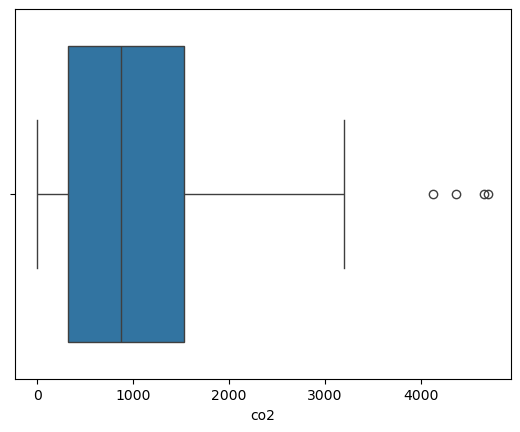

In [18]:
sns.boxplot(data=petrol_cars, x="co2")
plt.show()

In [19]:
# Apply Tukey's fence to filter for outlier values

LQ = petrol_cars["co2"].quantile(0.25)
UQ = petrol_cars["co2"].quantile(0.75)
IQR = UQ - LQ
tukey_fence_upper = UQ + (1.5 * IQR)
cond_tukey_fence_upper = petrol_cars["co2"] > tukey_fence_upper

outliers = petrol_cars[cond_tukey_fence_upper].reset_index()
outliers

,index,LAEI 1km2 ID,Latitude,Longitude,Source,co2,Emissions Unit
0,416947,12113.0,51.393537,-0.255023,Car - Petrol,4367.327816,tonnes/annum
1,416968,12454.0,51.376196,-0.298789,Car - Petrol,4134.225591,tonnes/annum
2,417429,11766.0,51.412147,-0.297456,Car - Petrol,4707.255276,tonnes/annum
3,417483,12455.0,51.375986,-0.284428,Car - Petrol,4665.445721,tonnes/annum


## Visualise the emissions data

In [20]:
# plot Kingston LAEI grid squares
grid_boundaries = gpd.read_file("LAEI2019_grid.shp")
grid_boundaries.head()

,Grid_ID_19,GridIdEx,1km2_ID,Easting,Northing,Area_km2,Borough,Zone,geometry
0,1,1,5910,510500,203500,1.0,NonGLA,NonGLA,"POLYGON ((511000.001 203000.001, 509999.999 20..."
1,2,2,5911,511500,203500,1.0,NonGLA,NonGLA,"POLYGON ((512000.003 203000.001, 511000.001 20..."
2,3,3,5912,512500,203500,1.0,NonGLA,NonGLA,"POLYGON ((512999.997 203000.001, 512000.003 20..."
3,4,4,5915,515500,203500,1.0,NonGLA,NonGLA,"POLYGON ((516000.004 203000.001, 515000.002 20..."
4,5,5,5916,516500,203500,1.0,NonGLA,NonGLA,"POLYGON ((516999.998 203000.001, 516000.004 20..."


In [25]:
petrol_cars = petrol_cars.merge(grid_boundaries, how="left", left_on="LAEI 1km2 ID", right_on="1km2_ID")
petrol_cars

,LAEI 1km2 ID,Latitude,Longitude,Source,co2,Emissions Unit,Grid_ID_19_x,GridIdEx_x,1km2_ID_x,Easting_x,...,geometry_x,Grid_ID_19_y,GridIdEx_y,1km2_ID_y,Easting_y,Northing_y,Area_km2_y,Borough_y,Zone_y,geometry_y
0,11253.0,51.438475,-0.253311,Car - Petrol,848.124716,tonnes/annum,869,997,11253,521500,...,"POLYGON ((522000.001 172740.613, 521920.898 17...",869,997,11253,521500,172500,0.61,Richmond,OuterULEX,"POLYGON ((522000.001 172740.613, 521920.898 17..."
1,11253.0,51.438475,-0.253311,Car - Petrol,848.124716,tonnes/annum,869,997,11253,521500,...,"POLYGON ((522000.001 172740.613, 521920.898 17...",870,998,11253,521500,172500,0.27,Wandsworth,OuterULEX,"POLYGON ((522000.001 172000.005, 521663.479 17..."
2,11253.0,51.438475,-0.253311,Car - Petrol,848.124716,tonnes/annum,869,997,11253,521500,...,"POLYGON ((522000.001 172740.613, 521920.898 17...",871,999,11253,521500,172500,0.12,Kingston,OuterULEX,"POLYGON ((521663.479 172000.005, 520999.998 17..."
3,11253.0,51.438475,-0.253311,Car - Petrol,848.124716,tonnes/annum,870,998,11253,521500,...,"POLYGON ((522000.001 172000.005, 521663.479 17...",869,997,11253,521500,172500,0.61,Richmond,OuterULEX,"POLYGON ((522000.001 172740.613, 521920.898 17..."
4,11253.0,51.438475,-0.253311,Car - Petrol,848.124716,tonnes/annum,870,998,11253,521500,...,"POLYGON ((522000.001 172000.005, 521663.479 17...",870,998,11253,521500,172500,0.27,Wandsworth,OuterULEX,"POLYGON ((522000.001 172000.005, 521663.479 17..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,12799.0,51.358011,-0.285099,Car - Petrol,256.200872,tonnes/annum,2641,3158,12799,519500,...,"POLYGON ((519999.996 163000.001, 519000.002 16...",2641,3158,12799,519500,163500,0.78,NonGLA,NonGLA,"POLYGON ((519999.996 163000.001, 519000.002 16..."
201,12799.0,51.358011,-0.285099,Car - Petrol,256.200872,tonnes/annum,2641,3158,12799,519500,...,"POLYGON ((519999.996 163000.001, 519000.002 16...",2642,3159,12799,519500,163500,0.22,Kingston,OuterULEX,"POLYGON ((519000.002 163026.233, 519000.002 16..."
202,12799.0,51.358011,-0.285099,Car - Petrol,256.200872,tonnes/annum,2642,3159,12799,519500,...,"POLYGON ((519000.002 163026.233, 519000.002 16...",2641,3158,12799,519500,163500,0.78,NonGLA,NonGLA,"POLYGON ((519999.996 163000.001, 519000.002 16..."
203,12799.0,51.358011,-0.285099,Car - Petrol,256.200872,tonnes/annum,2642,3159,12799,519500,...,"POLYGON ((519000.002 163026.233, 519000.002 16...",2642,3159,12799,519500,163500,0.22,Kingston,OuterULEX,"POLYGON ((519000.002 163026.233, 519000.002 16..."


In [23]:
help(folium.Choropleth)

Help on class Choropleth in module folium.features:

class Choropleth(folium.map.FeatureGroup)
 |  Choropleth(
 |      geo_data: Any,
 |      data: Optional[Any] = None,
 |      columns: Optional[Sequence[Any]] = None,
 |      key_on: Optional[str] = None,
 |      bins: Union[int, Sequence[float]] = 6,
 |      fill_color: Optional[str] = None,
 |      nan_fill_color: str = 'black',
 |      fill_opacity: float = 0.6,
 |      nan_fill_opacity: Optional[float] = None,
 |      line_color: str = 'black',
 |      line_weight: float = 1,
 |      line_opacity: float = 1,
 |      name: Optional[str] = None,
 |      legend_name: str = '',
 |      overlay: bool = True,
 |      control: bool = True,
 |      show: bool = True,
 |      topojson: Optional[str] = None,
 |      smooth_factor: Optional[float] = None,
 |      highlight: bool = False,
 |      use_jenks: bool = False,
 |      **kwargs
 |  )
 |
 |  Apply a GeoJSON overlay to the map.
 |
 |  Plot a GeoJSON overlay on the base map. There is n

In [24]:
kingston_coords = [51.4123, -0.3007]
m1 = folium.Map(location=kingston_coords, zoom_start=12)

folium.Choropleth(
    geo_data=petrol_cars,
    name="choropleth",
    columns=["co2"],
    fill_color="viridis",
    legend_name="CO2 emissions (tonnes/annum)",
).add_to(m1)

# plot Kingston boundary
folium.GeoJson(fname_boundary).add_to(m1)

m1

ValueError: Cannot render objects with any missing geometries:      LAEI 1km2 ID   Latitude  Longitude        Source          co2  \
0         11253.0  51.438475  -0.253311  Car - Petrol   848.124716   
1         11253.0  51.438475  -0.253311  Car - Petrol   848.124716   
2         11253.0  51.438475  -0.253311  Car - Petrol   848.124716   
3         11593.0  51.421343  -0.311498  Car - Petrol   159.352206   
4         11593.0  51.421343  -0.311498  Car - Petrol   159.352206   
..            ...        ...        ...           ...          ...   
98        12797.0  51.358427  -0.313810  Car - Petrol  1158.250194   
99        12797.0  51.358427  -0.313810  Car - Petrol  1158.250194   
100       12799.0  51.358011  -0.285099  Car - Petrol   256.200872   
101       12799.0  51.358011  -0.285099  Car - Petrol   256.200872   
102       13141.0  51.340452  -0.314470  Car - Petrol  1016.085575   

    Emissions Unit  Grid_ID_19  GridIdEx  1km2_ID  Easting  Northing  \
0     tonnes/annum      

In [71]:
kingston_coords = [51.4123, -0.3007]
m1 = folium.Map(location=kingston_coords, zoom_start=12)

for i in range(len(outliers)):
    folium.Marker(
        location=[outliers["Latitude"][i], outliers["Longitude"][i]],
        tooltip=str(round(outliers["co2"][i], 2)) + " of CO2 tonnes per annum"
    ).add_to(m1)

# plot Kingston boundary
folium.GeoJson(fname_boundary).add_to(m1)

# plot Kingston LAEI grid squares
grid_boundaries = gpd.read_file("LAEI2019_grid.shp")
petrol_cars = petrol_cars.merge(grid_boundaries, how="left", left_on="
folium.GeoJson(grid_boundaries[grid_boundaries["Borough"] == "Kingston"]).add_to(m1)

m1